In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import numpy as np

In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="student",
    password="myStrongPass123",
    database="kaggle_db"
)

#  Graph 1: Offensive Efficiency vs Wins

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\3880952634.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


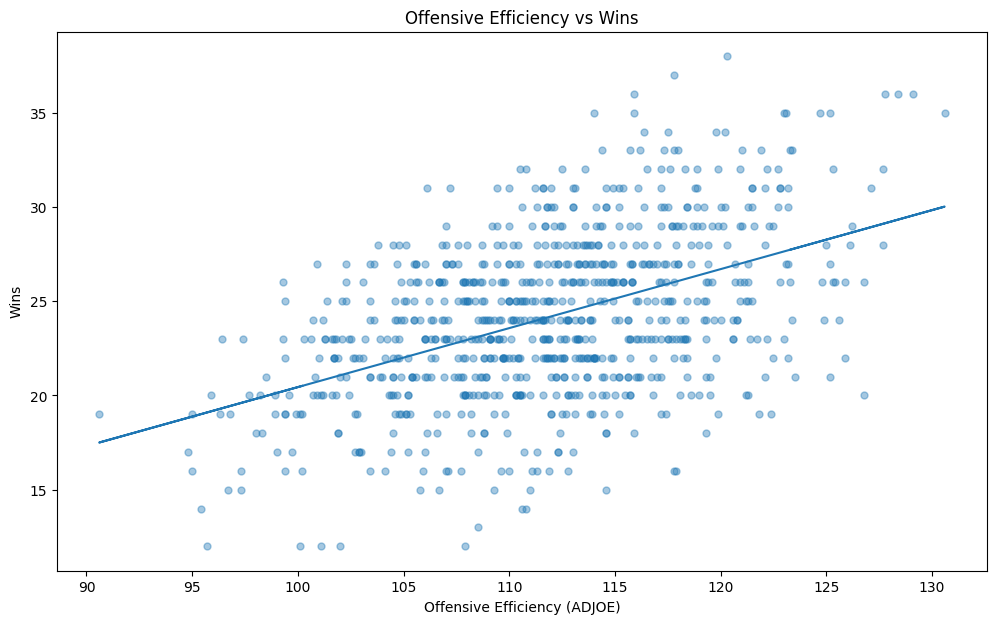

In [ ]:
query = """
SELECT
TEAM,
YEAR,
W AS wins,
ADJOE AS offensive_efficiency
FROM cbb
WHERE W IS NOT NULL
AND ADJOE IS NOT NULL;
"""

_df = pd.read_sql(query, conn)

x = _df['offensive_efficiency']
y = _df['wins']

plt.figure(figsize=(12,7))

plt.scatter(x, y, alpha=0.4, s=25)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel('Offensive Efficiency (ADJOE)')
plt.ylabel('Wins')
plt.title('Offensive Efficiency vs Wins')

plt.show()

# Graph 2 :  Defensive Efficiency vs Wins

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\2786310958.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


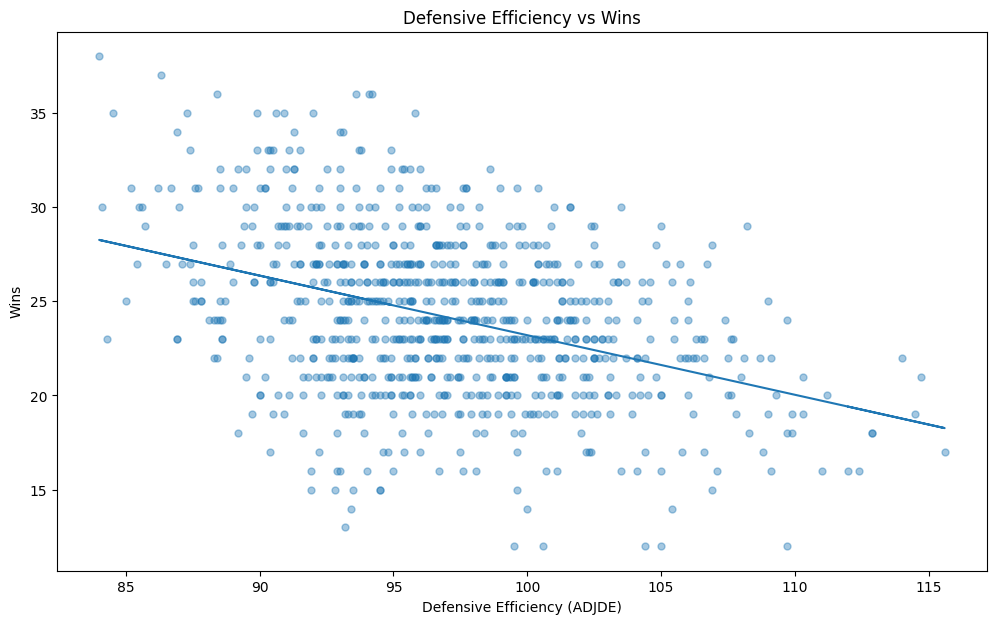

In [ ]:
query = """
SELECT
TEAM,
YEAR,
W AS wins,
ADJDE AS defensive_efficiency
FROM cbb
WHERE W IS NOT NULL
AND ADJDE IS NOT NULL;
"""

_df = pd.read_sql(query, conn)

x = _df['defensive_efficiency']
y = _df['wins']

plt.figure(figsize=(12,7))

plt.scatter(x, y, alpha=0.4, s=25)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel('Defensive Efficiency (ADJDE)')
plt.ylabel('Wins')
plt.title('Defensive Efficiency vs Wins')

plt.show()

# Graph 3 : Tournament Seed vs Drafted Players

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\2148046491.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


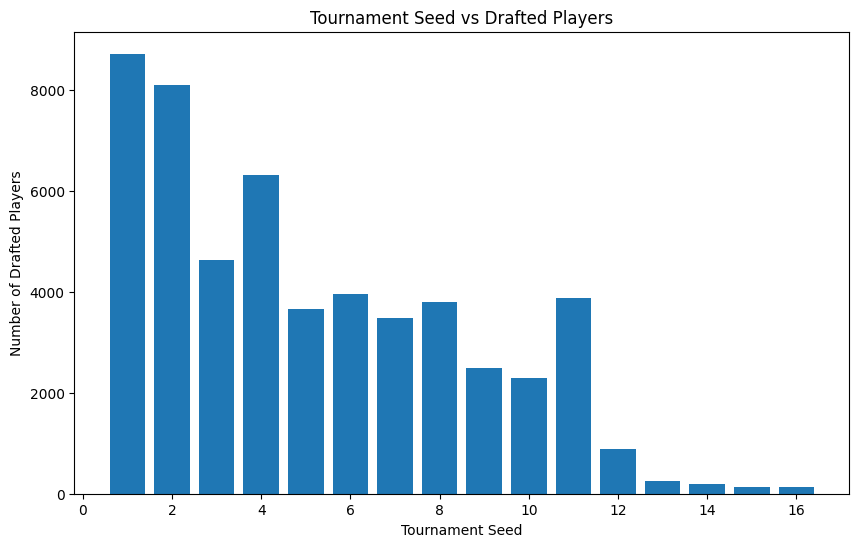

In [ ]:
query = """
SELECT
    seed,
    COUNT(*) AS drafted_players
FROM cbb c
JOIN draft_data d
ON c.TEAM = d.college
WHERE seed > 0
GROUP BY seed
ORDER BY seed;
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
plt.bar(_df['seed'], _df['drafted_players'])
plt.xlabel('Tournament Seed')
plt.ylabel('Number of Drafted Players')
plt.title('Tournament Seed vs Drafted Players')
plt.show()

# Graph 4 : Draft Pick vs NBA Points Per Game

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\2979751707.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


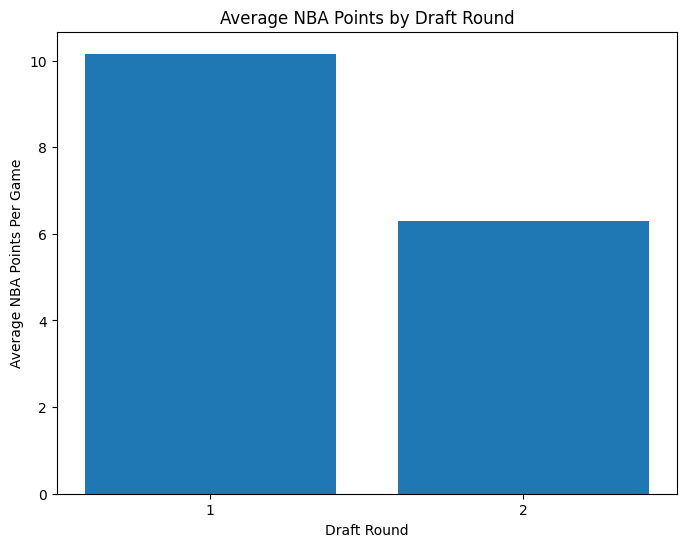

In [ ]:
query = """
SELECT
draft_round,
ROUND(AVG(pts),2) AS avg_points
FROM nba
WHERE pts IS NOT NULL
AND draft_round IN (1,2)
GROUP BY draft_round
ORDER BY draft_round;
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(8,6))
plt.bar(_df['draft_round'].astype(str), _df['avg_points'])

plt.xlabel('Draft Round')
plt.ylabel('Average NBA Points Per Game')
plt.title('Average NBA Points by Draft Round')

plt.show()

# Graph 5: Average NBA Points by Draft Pick

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\1228145907.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


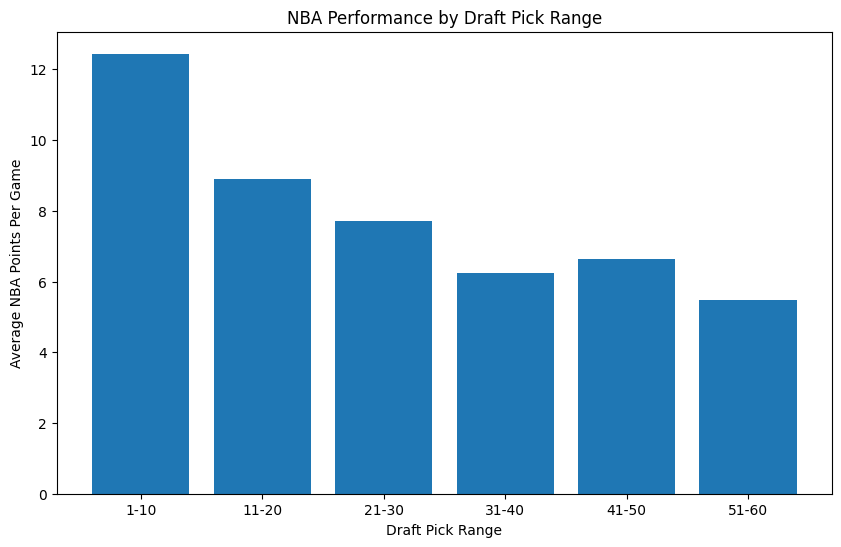

In [ ]:
query = """
SELECT
CASE
WHEN draft_number BETWEEN 1 AND 10 THEN '1-10'
WHEN draft_number BETWEEN 11 AND 20 THEN '11-20'
WHEN draft_number BETWEEN 21 AND 30 THEN '21-30'
WHEN draft_number BETWEEN 31 AND 40 THEN '31-40'
WHEN draft_number BETWEEN 41 AND 50 THEN '41-50'
WHEN draft_number BETWEEN 51 AND 60 THEN '51-60'
END AS draft_range,

ROUND(AVG(pts),2) AS avg_points,
COUNT(*) AS players

FROM nba

WHERE draft_number BETWEEN 1 AND 60
AND pts IS NOT NULL

GROUP BY draft_range

ORDER BY MIN(draft_number);
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

plt.bar(_df['draft_range'], _df['avg_points'])

plt.xlabel('Draft Pick Range')
plt.ylabel('Average NBA Points Per Game')
plt.title('NBA Performance by Draft Pick Range')

plt.show()

# Graph 6 : Colleges that Produced the Most NBA Players

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\4199936129.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


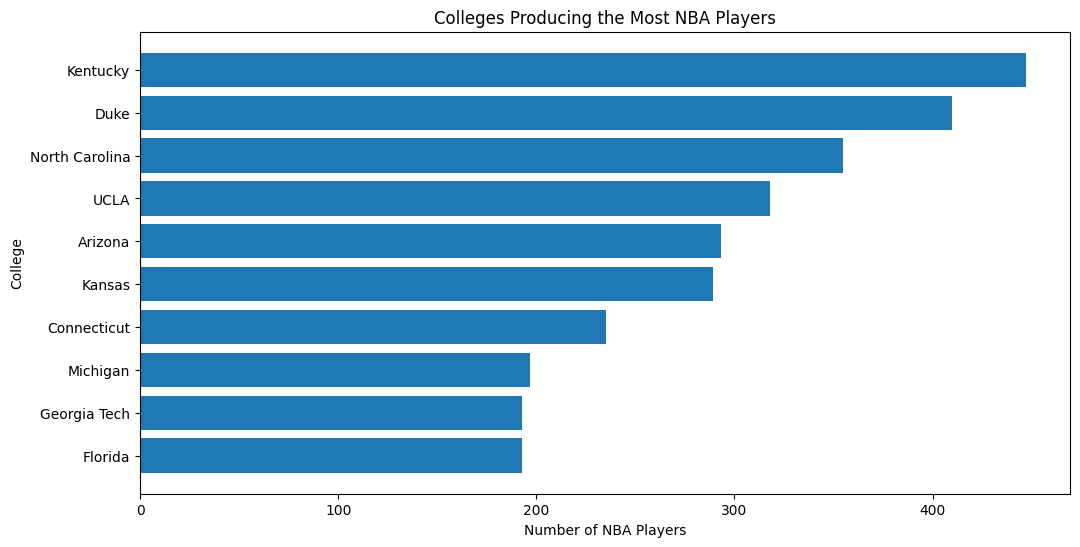

In [ ]:
query = """
SELECT
college,
COUNT(*) AS nba_players
FROM draft_data
WHERE college IS NOT NULL
AND college != 'None'
GROUP BY college
ORDER BY nba_players DESC
LIMIT 10;
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
plt.barh(_df['college'], _df['nba_players'])

plt.xlabel('Number of NBA Players')
plt.ylabel('College')
plt.title('Colleges Producing the Most NBA Players')

plt.gca().invert_yaxis()

plt.show()

# Graph 7: Top Countries producing NBA Players

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\1355712509.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


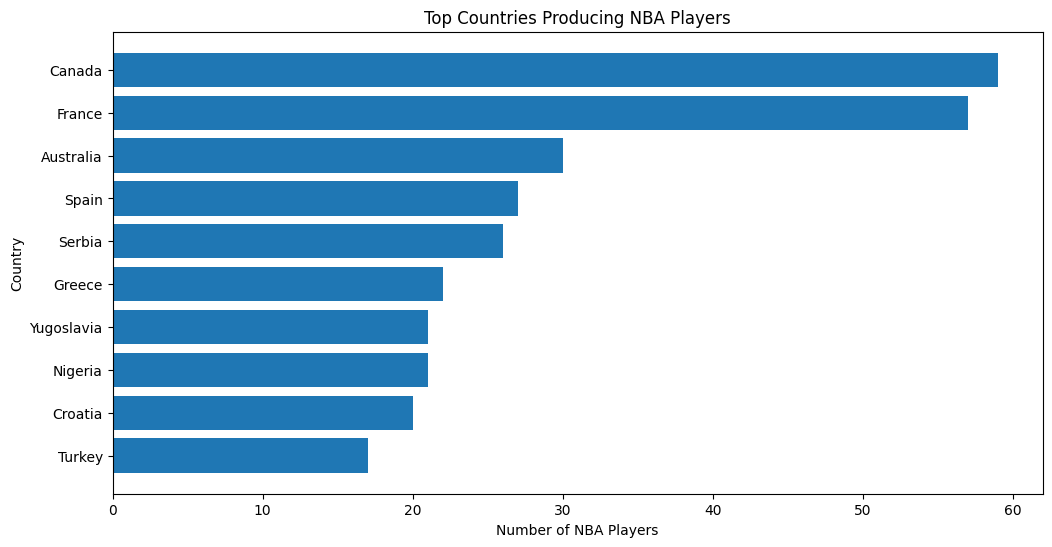

In [ ]:
query = """
SELECT
Nationality,
COUNT(*) AS total_players
FROM international_players
WHERE Nationality IS NOT NULL
GROUP BY Nationality
ORDER BY total_players DESC
LIMIT 10;
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
plt.barh(_df['Nationality'], _df['total_players'])

plt.xlabel('Number of NBA Players')
plt.ylabel('Country')
plt.title('Top Countries Producing NBA Players')

plt.gca().invert_yaxis()

plt.show()

# Graph 8 : International Players by NBA Team

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\1071309761.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


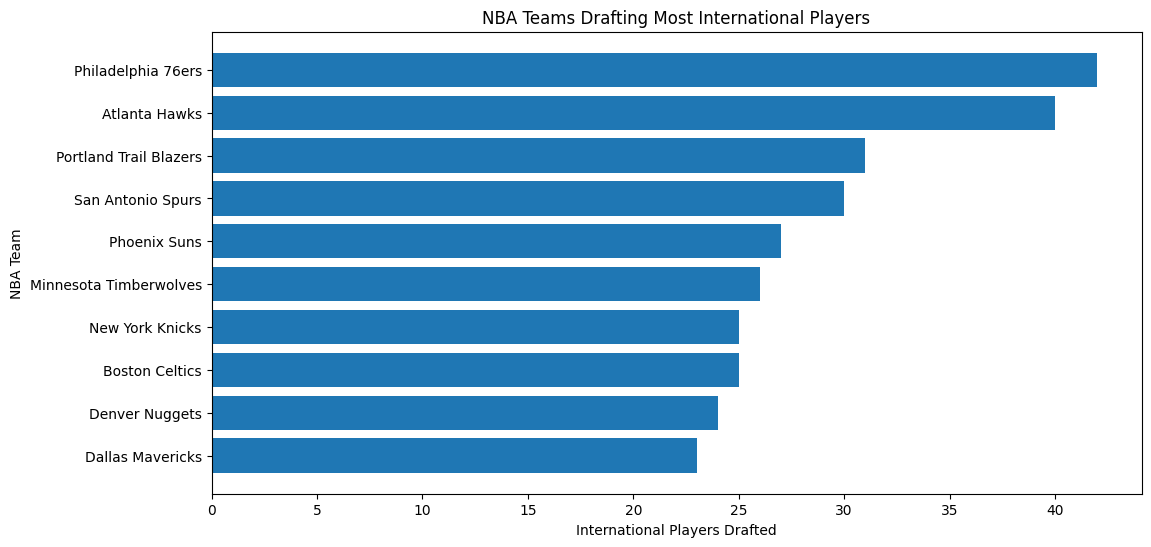

In [ ]:
query = """
SELECT
`Picked by`,
COUNT(*) AS international_players
FROM international_players
WHERE `Picked by` IS NOT NULL
GROUP BY `Picked by`
ORDER BY international_players DESC
LIMIT 10;
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
plt.barh(_df['Picked by'], _df['international_players'])

plt.xlabel('International Players Drafted')
plt.ylabel('NBA Team')
plt.title('NBA Teams Drafting Most International Players')

plt.gca().invert_yaxis()

plt.show()

# Graph 9: Average Draft Position by Country

C:\Users\antal\AppData\Local\Temp\ipykernel_19252\2699887144.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  _df = pd.read_sql(query, conn)


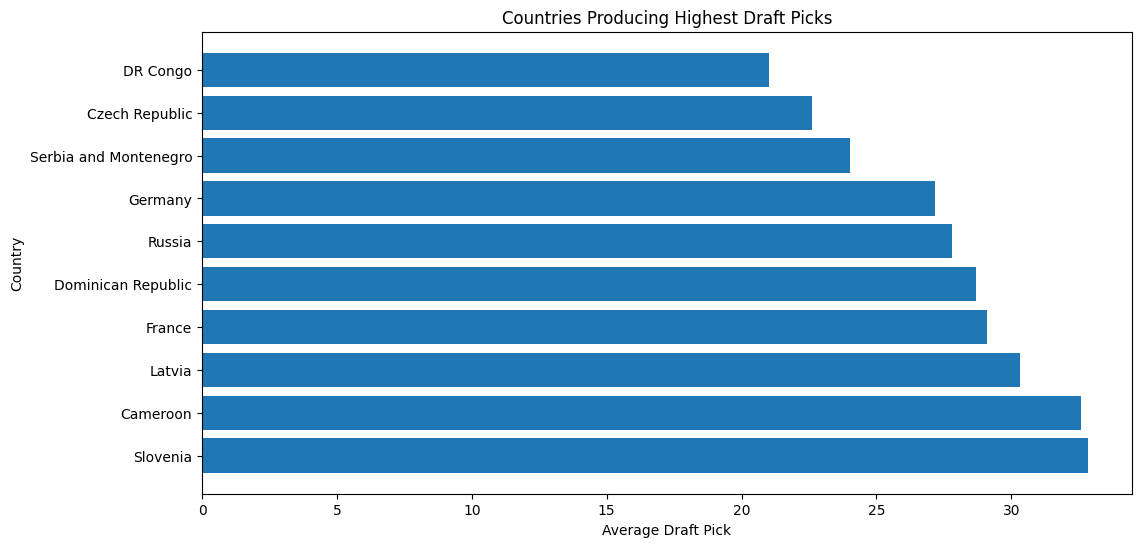

In [ ]:
query = """
SELECT
nationality,
ROUND(AVG(Pick),2) AS avg_draft_pick
FROM international_players
WHERE Pick IS NOT NULL
GROUP BY nationality
HAVING COUNT(*) >= 5
ORDER BY avg_draft_pick ASC
LIMIT 10;
"""

_df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
plt.barh(_df['nationality'], _df['avg_draft_pick'])

plt.xlabel('Average Draft Pick')
plt.ylabel('Country')
plt.title('Countries Producing Highest Draft Picks')

plt.gca().invert_yaxis()

plt.show()